# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari *Kaggle* : https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

2. **Perkenalan Dataset**
   Pada proyek ini, saya menggunakan Heart Disease Dataset yang tersedia di Kaggle. Dataset ini berisi informasi klinis pasien yang digunakan untuk memprediksi apakah seseorang memiliki penyakit jantung atau tidak. Data ini bersumber dari beberapa studi kesehatan dan telah menjadi salah satu dataset standar untuk eksperimen klasifikasi di bidang machine learning.

   Dataset terdiri dari 303 baris dan 14 fitur, yang mencakup karakteristik demografis, indikator kesehatan, dan hasil tes medis. Beberapa fitur penting di antaranya:

   * age — usia pasien
   * sex — jenis kelamin
   * cp — tipe nyeri dada (chest pain type)
   * trestbps — tekanan darah istirahat
   * chol — kadar kolesterol
   * fbs — gula darah puasa
   * restecg — hasil elektrokardiografi
   * thalach — denyut jantung maksimum
   * exang — angina yang diinduksi oleh olahraga
   * oldpeak — depresi ST yang disebabkan oleh olahraga
   * ca, thal — hasil pemeriksaan tambahan

   target — variabel yang diprediksi; bernilai 1 jika pasien terindikasi penyakit jantung dan 0 jika tidak

   Dataset ini digunakan untuk membangun model klasifikasi yang dapat memprediksi kemungkinan seseorang memiliki penyakit jantung berdasarkan fitur-fitur tersebut.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [4]:
#Type your code here
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [5]:
df = pd.read_csv("heart_raw.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [7]:
#Cek Missing Values
df.isnull().sum()


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


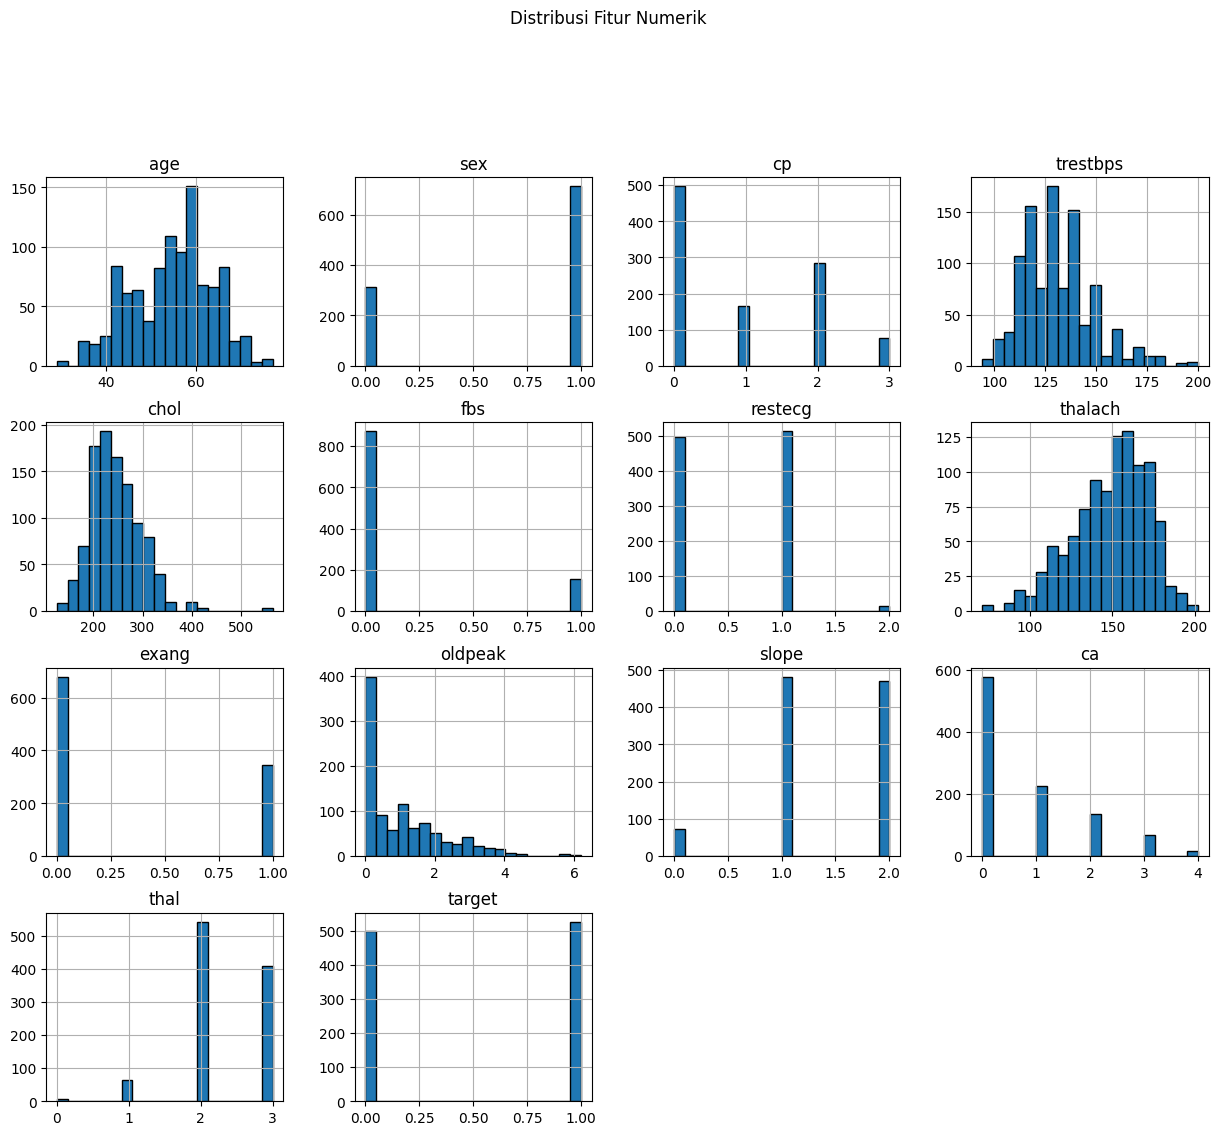

In [8]:
df.hist(figsize=(15, 12), bins=20, edgecolor='black')
plt.suptitle("Distribusi Fitur Numerik", y=1.02)
plt.show()


<Axes: xlabel='cp', ylabel='count'>

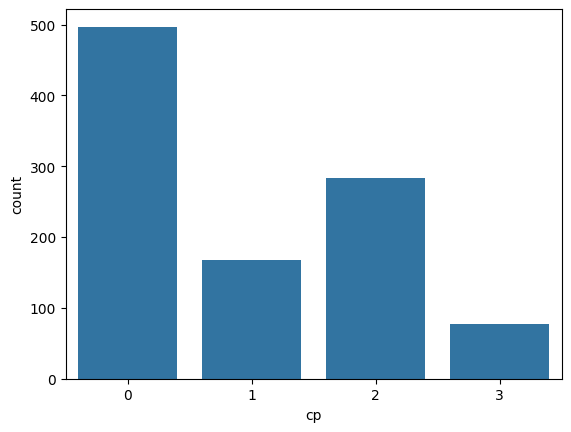

In [9]:
import seaborn as sns
sns.countplot(x="cp", data=df)

<Axes: xlabel='target', ylabel='count'>

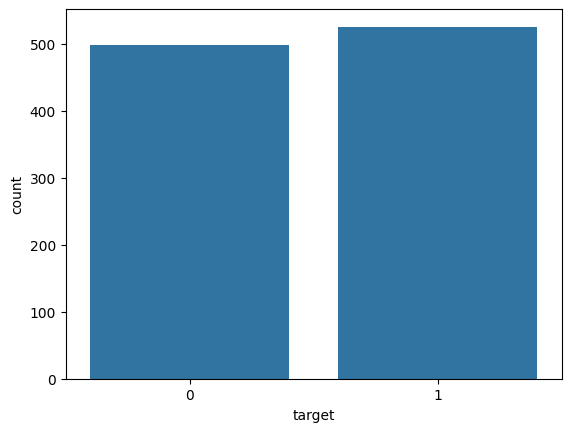

In [10]:
#Distribusi target
sns.countplot(x="target", data=df)

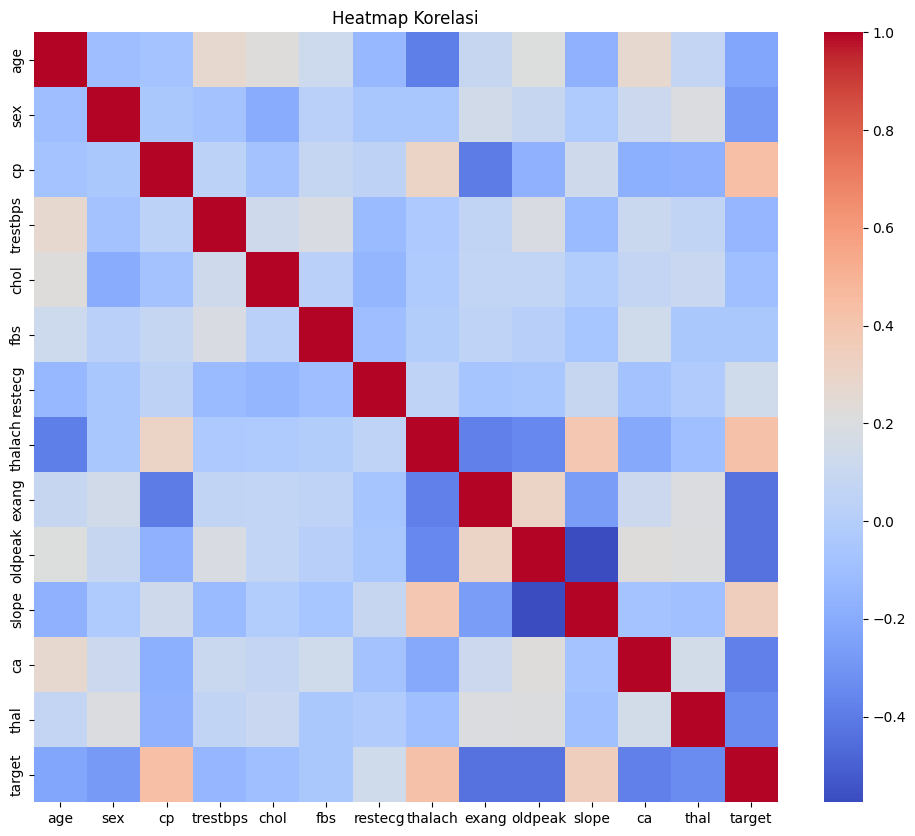

In [11]:
#korelasi antar fitur
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Heatmap Korelasi")
plt.show()



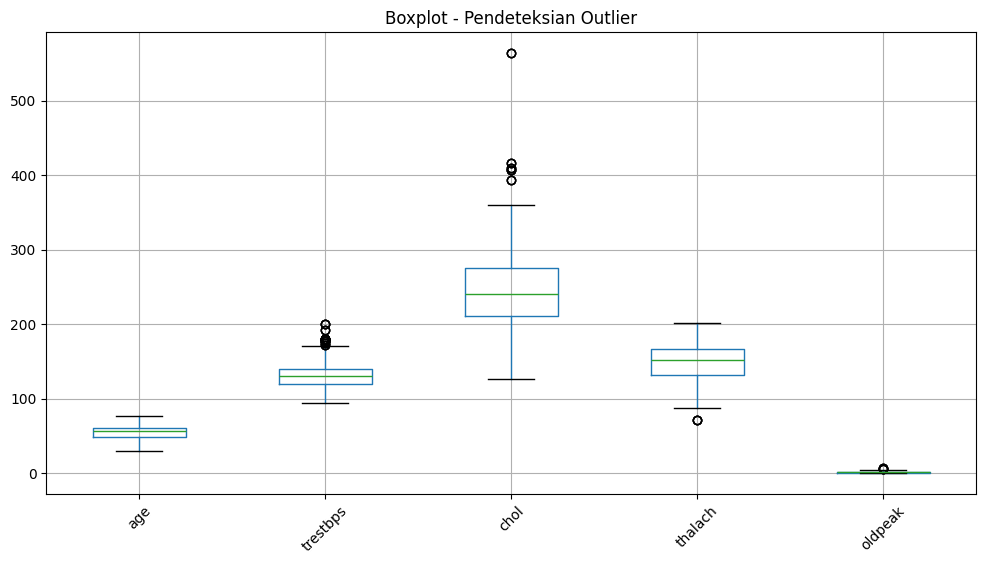

In [12]:
#cek outlier boxplot
numeric_cols = ['age','trestbps','chol','thalach','oldpeak']

plt.figure(figsize=(12,6))
df[numeric_cols].boxplot()
plt.title("Boxplot - Pendeteksian Outlier")
plt.xticks(rotation=45)
plt.show()


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [13]:
#Memisahkan fitur dan targer
X = df.drop("target", axis=1)
y = df["target"]

In [14]:
#menentukan fitur kategorikan & numerik
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]


In [15]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Fit & transform
X_processed = preprocessor.fit_transform(X)

# Convert ke dense array (universal handling)
import numpy as np

if hasattr(X_processed, "toarray"):
    X_processed_dense = X_processed.toarray()
else:
    X_processed_dense = X_processed

# Convert ke DataFrame
processed_df = pd.DataFrame(X_processed_dense)
processed_df["target"] = y.values

processed_df.head()


,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,target
0,-0.268437,-0.377636,-0.659332,0.821321,-0.060888,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0
1,-0.158157,0.479107,-0.833861,0.255968,1.727137,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
2,1.716595,0.764688,-1.396233,-1.048692,1.301417,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
3,0.724079,0.936037,-0.833861,0.516900,-0.912329,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
4,0.834359,0.364875,0.930822,-1.874977,0.705408,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0


In [23]:
processed_df.to_csv("preprocessing/heartdataset_preprocessing.csv", index=False)
